In [1]:
pip install python-bcb

In [2]:
import numpy as np
import pandas as pd


In [128]:
#biblioteca BANCO CENTRAL
from bcb import sgs

#blibioteca de modelagem estatistica
import statsmodels.api as sm

#biblioteca de visualização de dados
from matplotlib import pyplot as plt
from plotnine import *
plt.style.use('ggplot')

display(ipca.describe())


,ipca
count,121.000000
mean,0.417025
std,0.387932
min,-0.680000
25%,0.210000
50%,0.360000
75%,0.590000
max,1.620000


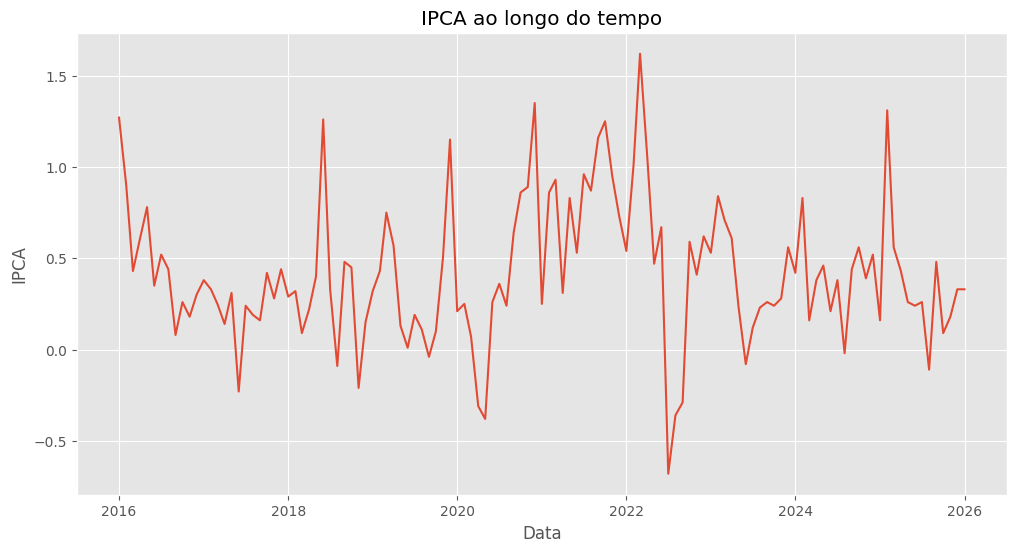

In [126]:
plt.figure(figsize=(12, 6))
plt.plot(ipca.index.to_timestamp(), ipca['ipca'])
plt.title('IPCA ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('IPCA')
plt.grid(True)
plt.show()

In [21]:
#decomposição sazonal aditiva do IPCA
decomposicao = sm.tsa.seasonal_decompose(ipca['ipca'], model='additive', period=12)

#remover o comportamento sazonal do IPCA para obter uma série ajustada (IPCA S.A.)
ipca_ajustada = ipca['ipca'] - decomposicao.seasonal

# Deslocar a série ajustada em 1 período
ipca_ajustada = ipca_ajustada.shift(1)

ipca_ajustada.dropna(inplace=True)

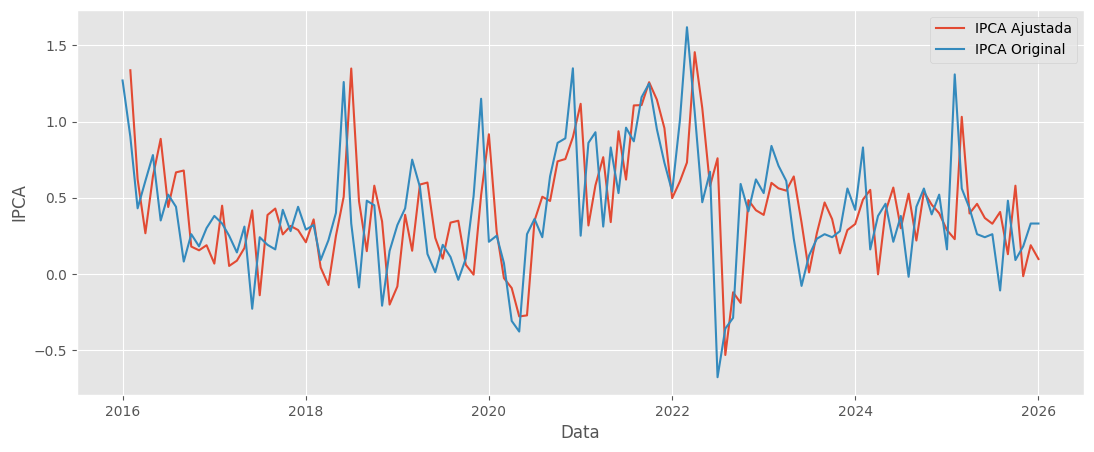

In [34]:
# separar os dados em variavel explanatorias (x_t) e dependente (y_t)

x_t=ipca_ajustada
y_t=ipca['ipca']

#plot do IPCA mensal ajustada sazonalmentesubplots(figsize=(13,5))
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(x_t.index.to_timestamp(), x_t, label='IPCA Ajustada')
ax.plot(y_t.index.to_timestamp(), y_t, label='IPCA Original')
ax.set_xlabel('Data')
ax.set_ylabel('IPCA')
ax.legend()
plt.show()

In [52]:
#definição da classe para a regressão om coeficiente variavel no tempo
class TVRegressao(sm.tsa.statespace.MLEModel):
  def __init__(self, y_t, x_t):
    #criação da matriz de variavel explicativas exogenas
    exog = sm.add_constant(x_t)

    #iniciação do modelo de espaço de estado com variáveis
    super(TVRegressao, self).__init__(endog=y_t, exog=exog, k_states=1, inicialização='difuse')



    #define a matriz de designe que varia no tempo
    self.ssm['design']=exog.T[np.newaxis, :, :]
    self.ssm['seleção']=np.eye(self.k_states)
    self.ssm['transicao']=np.zeros((self.k_states, self.k_states))
    self.ssm['observacao']=np.zeros((1, self.k_states))


    #indices dos parametros que precisam ser positivos variancias
    self.positive_params = slice(1,3)
def param_names(self):
  #nomes dos parametros do modelo
  return ['intercepto', 'var.e', 'var.x.coeff']

def start_params(self):

  exog=sm.add_constant(self.exog)
  res=sm.OLS(self.endog, exog).fit()
  params=np.r_(res.patams[0], res.scale, 0.001)
  return params

def transform_params(self, unconstrained):
  constrained=unconstrained.copy()
  constrained[self.positive_params]=np.exp(unconstrained[self.positive_params])
  return constrained

def loglikeobs(self, params):
  params=self.transform_params(params)
  exog=sm.add_constant(self.exog)
  return np

def untransform_params(self, constrained):
  unconstrained=constrained.copy()
  unconstrained[self.positive_params]=np.log(constrained[self.positive_params])
  return unconstrained


def update(self, params, **kwargs):
  params=super(TVRegressao, self).update(self, params, **kwargs)

  self['obs_intercept',0,0]=params[0]
  self['obs_cov',0,0]=params[1]
  self['state_cov']=np.diag(params[2:3])
  return self



In [24]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Alinhar y_t com o índice de x_t (ipca_ajustada)
y_t_aligned_for_model = y_t.loc[x_t.index] # Align y_t with the index of x_t

# Adicionar uma coluna constante a x_t para formar X_t_const
X_t_const = sm.add_constant(x_t, prepend=True) # Adding constant, prepend=True makes constant the first column

# Criar uma instância do modelo OLS
# y_t_aligned_for_model (variável dependente) e X_t_const (variáveis independentes) já estão preparados
modelo_ols = sm.OLS(y_t_aligned_for_model, X_t_const)

# Ajustar o modelo OLS aos dados
modelo_ols_resultado = modelo_ols.fit()

# Exibir o resumo dos resultados do modelo ajustado
print(modelo_ols_resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                   ipca   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     33.02
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           7.26e-08
Time:                        22:34:27   Log-Likelihood:                -39.349
No. Observations:                 120   AIC:                             82.70
Df Residuals:                     118   BIC:                             88.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2039      0.047      4.306      0.0

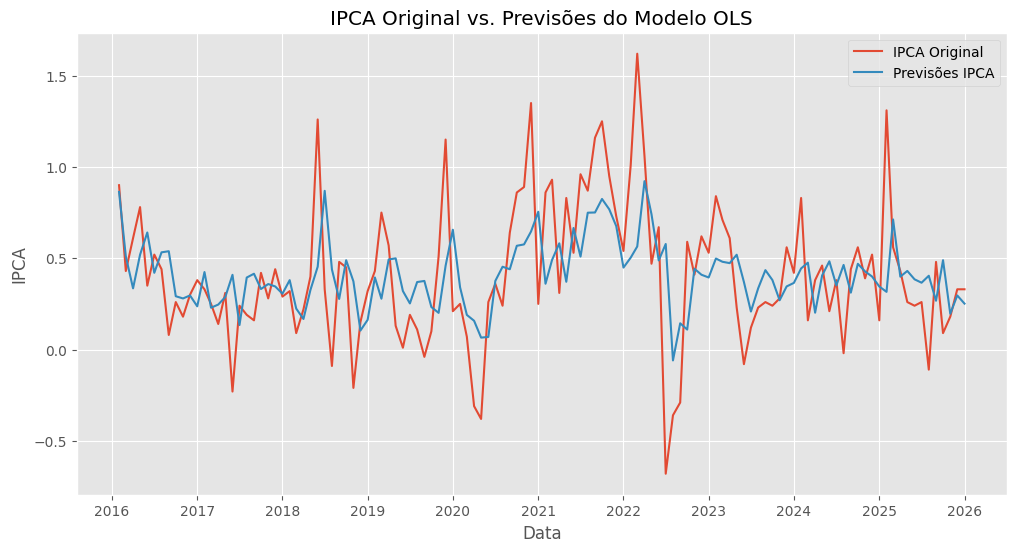

In [25]:
import matplotlib.pyplot as plt

# Gerar previsões usando o modelo OLS ajustado
previsoes_ipca = modelo_ols_resultado.predict(X_t_const)

# Plot IPCA original e previsões
plt.figure(figsize=(12, 6))
plt.plot(y_t_aligned_for_model.index.to_timestamp(), y_t_aligned_for_model, label='IPCA Original')
plt.plot(previsoes_ipca.index.to_timestamp(), previsoes_ipca, label='Previsões IPCA')
plt.title('IPCA Original vs. Previsões do Modelo OLS')
plt.xlabel('Data')
plt.ylabel('IPCA')
plt.legend()
plt.grid(True)
plt.show()

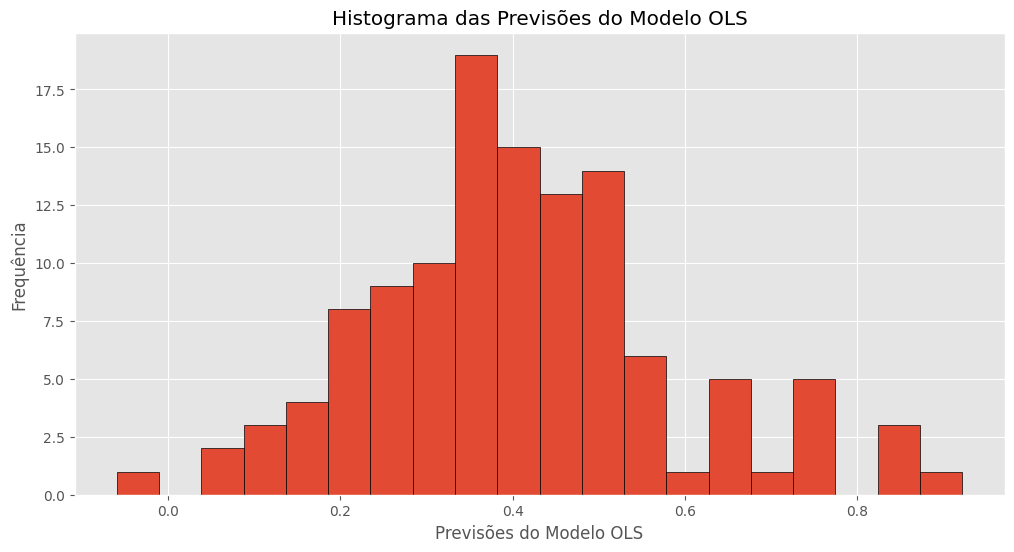

In [53]:
histograma = plt.figure(figsize=(12, 6))
plt.hist(previsoes_ipca, bins=20, edgecolor='black')
plt.title('Histograma das Previsões do Modelo OLS')
plt
plt.xlabel('Previsões do Modelo OLS')
plt.ylabel('Frequência')
plt.grid(True)
plt
plt.show()

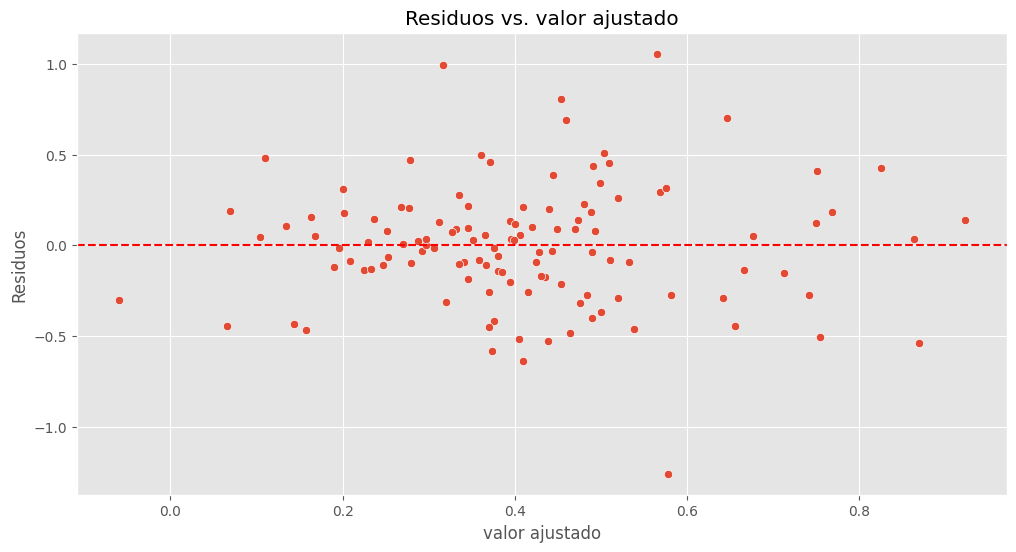

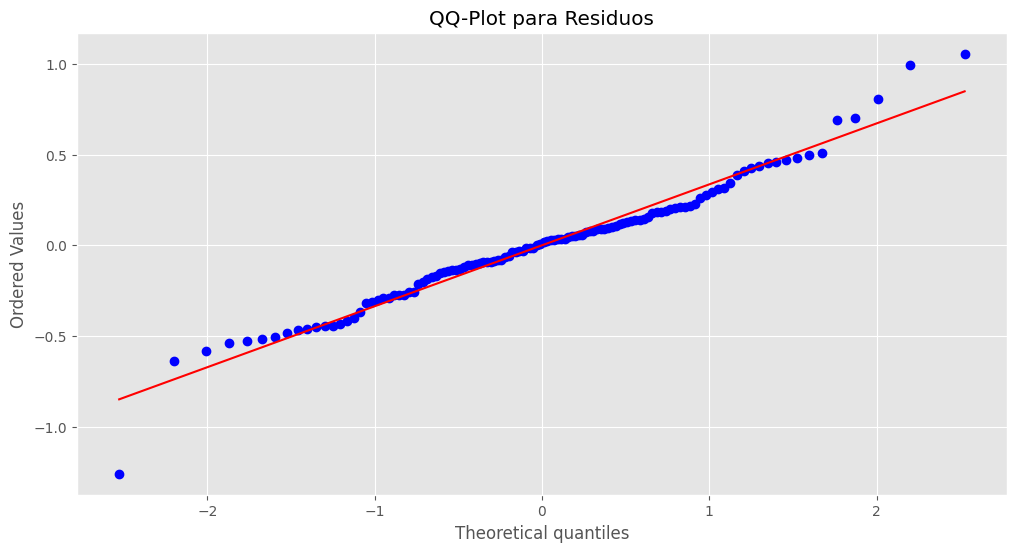

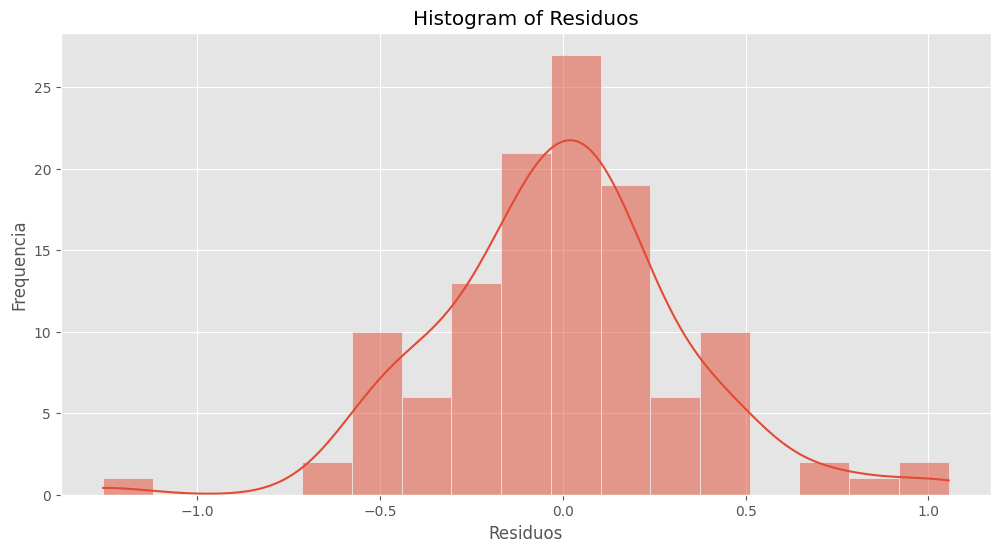

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Get residuos and valor ajustado
residuals = modelo_ols_resultado.resid
fitted_values = modelo_ols_resultado.fittedvalues

# Plot Residuos vs. valor ajustado
plt.figure(figsize=(12, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs. valor ajustado')
plt.xlabel('valor ajustado')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()

# Plot  QQ-Plot of Residuos
plt.figure(figsize=(12, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot para Residuos')
plt.grid(True)
plt.show()

# Plot  Histogram of Residuos
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frequencia')
plt.grid(True)
plt.show()

In [105]:
# Determinar a última data da série ipca_ajustada
last_date = ipca_ajustada.index.max()

# Criar um novo PeriodIndex para 12 meses futuros
future_dates = pd.period_range(start=last_date + 1, periods=12, freq='M')

# Para futuras previsões, assumir que ipca_ajustada se mantém constante no último valor observado
last_ipca_ajustada_value = ipca_ajustada.iloc[-1]
future_ipca_ajustada = pd.Series(last_ipca_ajustada_value, index=future_dates)

# Criar X_future explicitamente com colunas 'const' e '0', similar a X_t_const
X_future_data = {
    'const': np.ones(len(future_ipca_ajustada)),
    '0': future_ipca_ajustada.values
}
X_future = pd.DataFrame(X_future_data, index=future_dates)

# Gerar previsões futuras
previsoes_futuras_ipca = modelo_ols_resultado.predict(X_future)
previsoes_futuras_ipca = pd.Series(previsoes_futuras_ipca, index=future_dates)

print("Previsões futuras da IPCA (próximos 12 meses):")
display(previsoes_futuras_ipca)

Previsões futuras da IPCA (próximos 12 meses):


,0
2026-02,0.251548
2026-03,0.251548
2026-04,0.251548
2026-05,0.251548
2026-06,0.251548
2026-07,0.251548
2026-08,0.251548
2026-09,0.251548
2026-10,0.251548
2026-11,0.251548


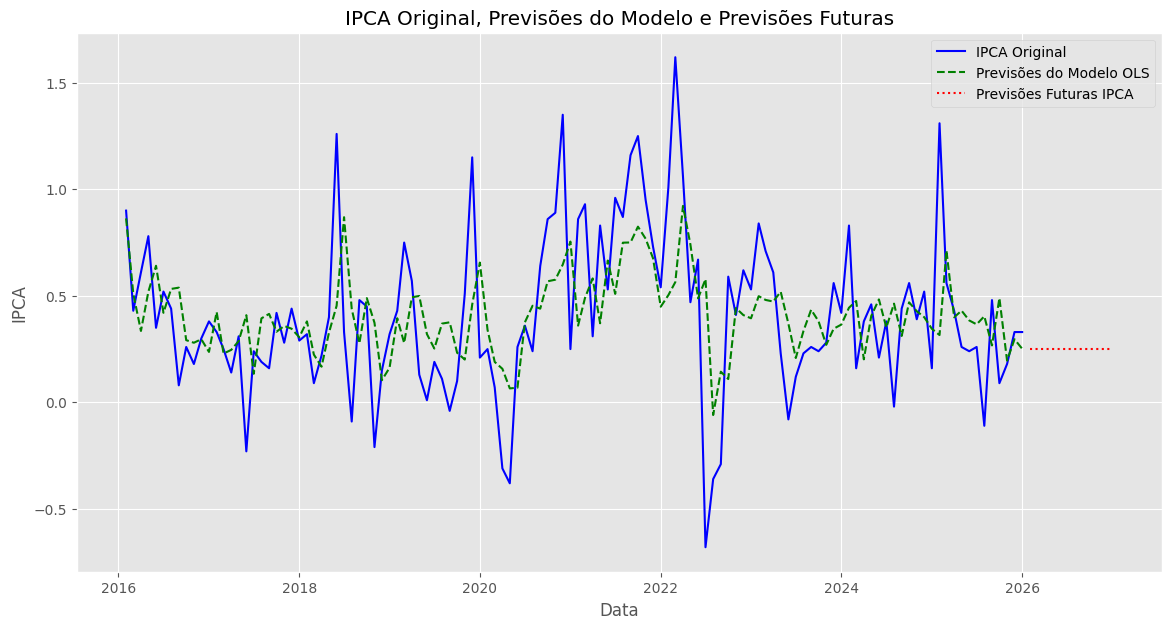

In [106]:
# Plotar IPCA Original, previsões do modelo e previsões futuras
plt.figure(figsize=(14, 7))

# IPCA Original
plt.plot(y_t_aligned_for_model.index.to_timestamp(), y_t_aligned_for_model, label='IPCA Original ', color='blue')

plt.plot(previsoes_ipca.index.to_timestamp(), previsoes_ipca, label='Previsões do Modelo OLS', color='green', linestyle='--')


plt.plot(previsoes_futuras_ipca.index.to_timestamp(), previsoes_futuras_ipca, label='Previsões Futuras IPCA', color='red', linestyle=':')

plt.title('IPCA Original, Previsões do Modelo e Previsões Futuras')
plt.xlabel('Data')
plt.ylabel('IPCA')
plt.legend()
plt.grid(True)
plt.show()

## Calculo de Intervalos de Predição Futuros com 95% de confiança


In [30]:
predictions = modelo_ols_resultado.get_prediction(exog=X_future)
prediction_intervals = predictions.summary_frame(alpha=0.05)

lower_bound_future = prediction_intervals['obs_ci_lower']
upper_bound_future = prediction_intervals['obs_ci_upper']

print("Lower bound for future IPCA predictions:")
display(lower_bound_future.head())
print("\nUpper bound for future IPCA predictions:")
display(upper_bound_future.head())

Lower bound for future IPCA predictions:


,obs_ci_lower
2026-02,-0.424177
2026-03,-0.424177
2026-04,-0.424177
2026-05,-0.424177
2026-06,-0.424177



Upper bound for future IPCA predictions:


,obs_ci_upper
2026-02,0.927272
2026-03,0.927272
2026-04,0.927272
2026-05,0.927272
2026-06,0.927272


In [104]:
predictions = modelo_ols_resultado.get_prediction(exog=X_future)
prediction_intervals = predictions.summary_frame(alpha=0.05)

lower_bound_future = prediction_intervals['obs_ci_lower']
upper_bound_future = prediction_intervals['obs_ci_upper']

print("Lower bound for future IPCA predictions:")
display(lower_bound_future.head())
print("\nUpper bound for future IPCA predictions:")
display(upper_bound_future.head())

Lower bound for future IPCA predictions:


,obs_ci_lower
2026-02,-0.424177
2026-03,-0.424177
2026-04,-0.424177
2026-05,-0.424177
2026-06,-0.424177



Upper bound for future IPCA predictions:


,obs_ci_upper
2026-02,0.927272
2026-03,0.927272
2026-04,0.927272
2026-05,0.927272
2026-06,0.927272


## Visualizar Previsões Futuras com Incerteza
Plotando o IPCA original, as previsões do modelo no período de treinamento, as previsões futuras e os intervalos de predição superiores e inferiores.


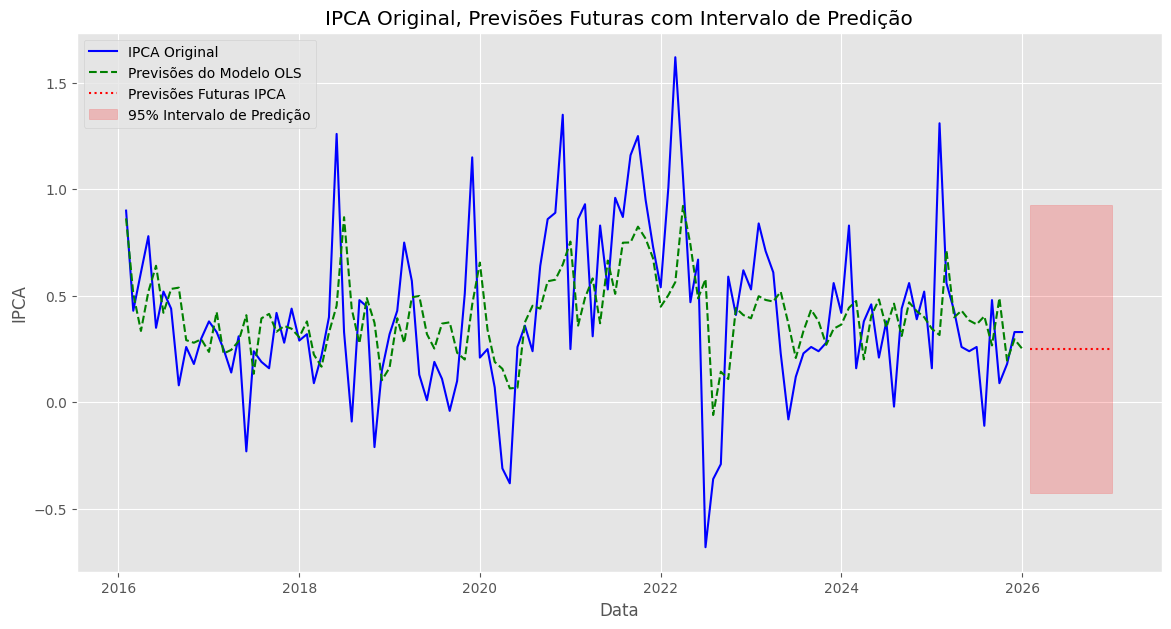

In [68]:
plt.figure(figsize=(14, 7))

# Plot Selic Original
plt.plot(y_t_aligned_for_model.index.to_timestamp(), y_t_aligned_for_model, label='IPCA Original', color='blue')

# Plot Previsões do Modelo (período de treinamento)
plt.plot(previsoes_ipca.index.to_timestamp(), previsoes_ipca, label='Previsões do Modelo OLS', color='green', linestyle='--')


plt.plot(previsoes_futuras_ipca.index.to_timestamp(), previsoes_futuras_ipca, label='Previsões Futuras IPCA', color='red', linestyle=':')

plt.fill_between(previsoes_futuras_ipca.index.to_timestamp(), lower_bound_future, upper_bound_future, color='red', alpha=0.2, label='95% Intervalo de Predição')

plt.title('IPCA Original, Previsões Futuras com Intervalo de Predição')
plt.xlabel('Data')
plt.ylabel('IPCA')
plt.legend()
plt.grid(True)
plt.show()

## Análise da Incerteza das Previsões Futuras do IPCA

Os intervalos de predição representam a faixa de valores dentro da qual esperamos que o IPCA futuro se encontre com um determinado nível de confiança (neste caso, 95%). A visualização do gráfico que inclui o IPCA original, as previsões do modelo e as previsões futuras com seus intervalos de predição oferece incerteza das estimativas



Utilizar o modelo ARIMA ajustado para gerar previsões futuras para o IPCA.


In [69]:

import statsmodels.api as sm
modelo_arima = sm.tsa.ARIMA(ipca['ipca'], order=(1, 2, 1))
modelo_arima_resultado = modelo_arima.fit()

print(modelo_arima_resultado.summary())

import pandas as pd
arima_previsoes_insample = modelo_arima_resultado.predict(start=0, end=len(ipca['ipca']) - 1)

last_date_original = ipca['ipca'].index.max()
start_forecast = last_date_original + 1
arima_previsoes_futuras = modelo_arima_resultado.forecast(steps=12)
arima_previsoes_futuras.index = pd.period_range(start=start_forecast, periods=12, freq='M')

print("Previsões ARIMA futuras (próximos 12 meses):")
display(arima_previsoes_futuras)



                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  121
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -53.901
Date:                Wed, 11 Mar 2026   AIC                            113.803
Time:                        03:12:59   BIC                            122.140
Sample:                    01-31-2016   HQIC                           117.188
                         - 01-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3302      0.085     -3.895      0.000      -0.496      -0.164
ma.L1         -0.9998      4.247     -0.235      0.814      -9.324       7.325
sigma2         0.1384      0.586      0.236      0.8

,predicted_mean
2026-02,0.320560
2026-03,0.314237
2026-04,0.306885
2026-05,0.299873
2026-06,0.292748
2026-07,0.285660
2026-08,0.278561
2026-09,0.271465
2026-10,0.264368
2026-11,0.257271


In [70]:
import statsmodels.api as sm
# Ajuste do modelo ARIMA
# Assumindo um modelo ARIMA(1,1,1) como um ponto de partida
# Os parâmetros p, d, q podem ser otimizados posteriormente
modelo_arima = sm.tsa.ARIMA(ipca['ipca'], order=(1, 2, 1))
modelo_arima_resultado = modelo_arima.fit()

print(modelo_arima_resultado.summary())


import pandas as pd

# Gerar previsões dentro da amostra (in-sample)
arima_previsoes_insample = modelo_arima_resultado.predict(start=0, end=len(ipca['ipca']) - 1)

#Determinar o ponto de início para as previsões futuras
last_date_original = ipca['ipca'].index.max()
start_forecast = last_date_original + 1

# Gerar previsões futuras (out-of-sample) para os próximos 12 meses
arima_previsoes_futuras = modelo_arima_resultado.forecast(steps=12)
arima_previsoes_futuras.index = pd.period_range(start=start_forecast, periods=12, freq='M')

#Exibir as primeiras entradas das arima_previsoes_futuras
print("Previsões ARIMA futuras (próximos 12 meses):")
display(arima_previsoes_futuras.head())

                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  121
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -53.901
Date:                Wed, 11 Mar 2026   AIC                            113.803
Time:                        03:13:11   BIC                            122.140
Sample:                    01-31-2016   HQIC                           117.188
                         - 01-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3302      0.085     -3.895      0.000      -0.496      -0.164
ma.L1         -0.9998      4.247     -0.235      0.814      -9.324       7.325
sigma2         0.1384      0.586      0.236      0.8

,predicted_mean
2026-02,0.320560
2026-03,0.314237
2026-04,0.306885
2026-05,0.299873
2026-06,0.292748


## Avaliar o Modelo ARIMA
Analisar o resumo do modelo ARIMA e os diagnósticos dos resíduos para avaliar seu desempenho e adequação.


In [71]:
print(modelo_arima_resultado.summary())

                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  121
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -53.901
Date:                Wed, 11 Mar 2026   AIC                            113.803
Time:                        03:13:18   BIC                            122.140
Sample:                    01-31-2016   HQIC                           117.188
                         - 01-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3302      0.085     -3.895      0.000      -0.496      -0.164
ma.L1         -0.9998      4.247     -0.235      0.814      -9.324       7.325
sigma2         0.1384      0.586      0.236      0.8

In [109]:
residuals_arima = modelo_arima_resultado.resid
print("Modelo ARIMA residual Extraido")

Modelo ARIMA residual Extraido


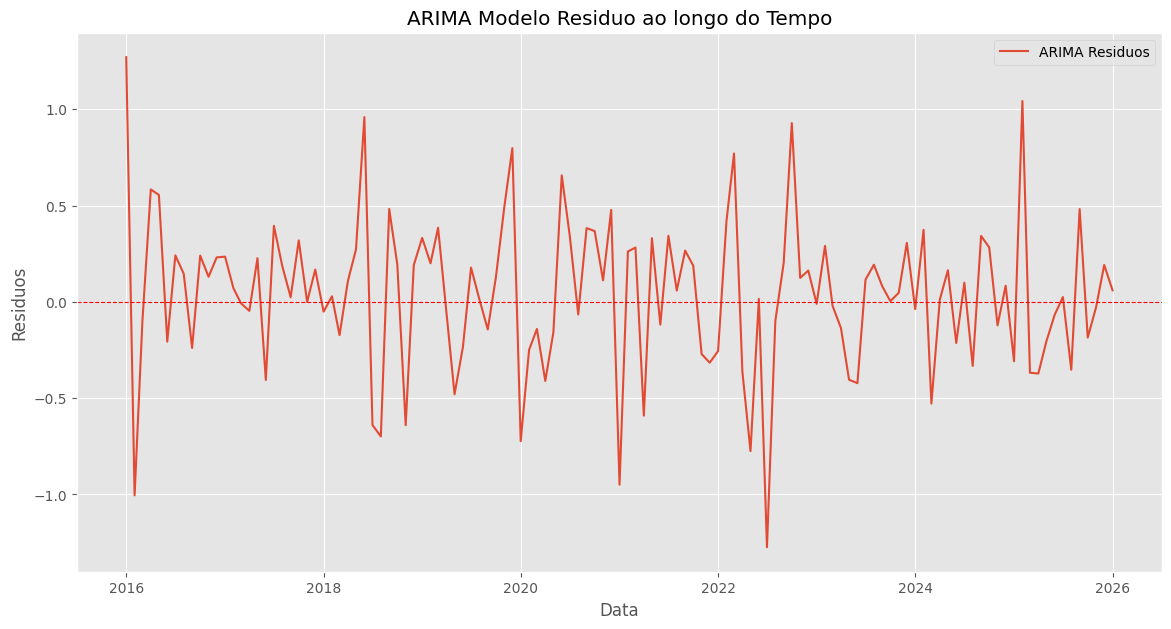

In [73]:
plt.figure(figsize=(14, 7))
plt.plot(residuals_arima.index.to_timestamp(), residuals_arima, label='ARIMA Residuos')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('ARIMA Modelo Residuo ao longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()

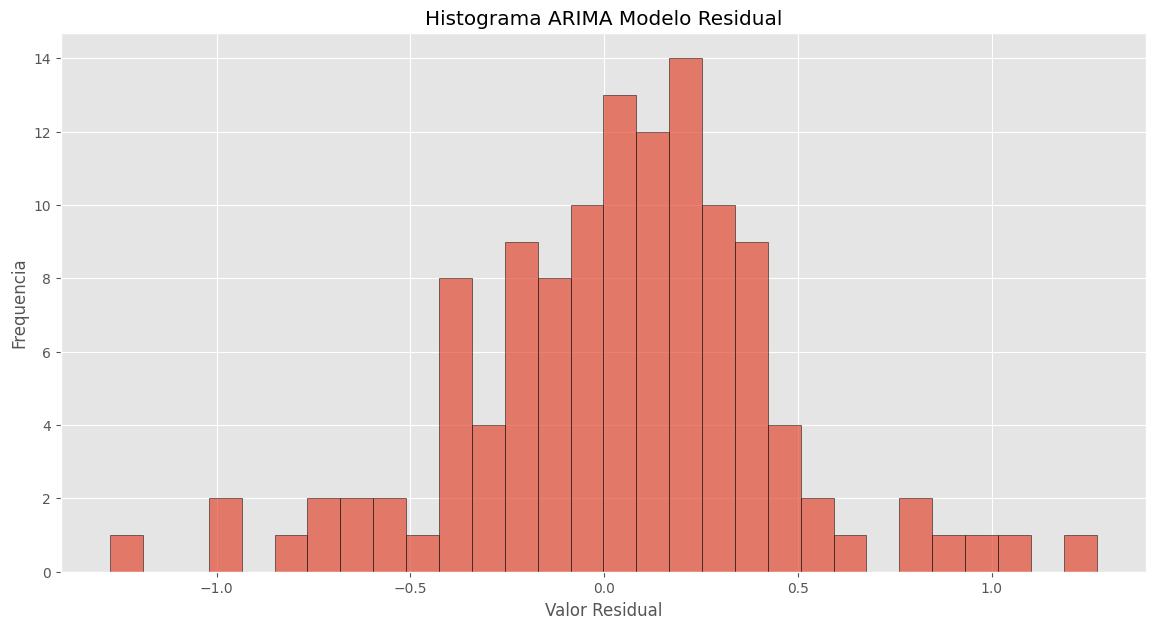

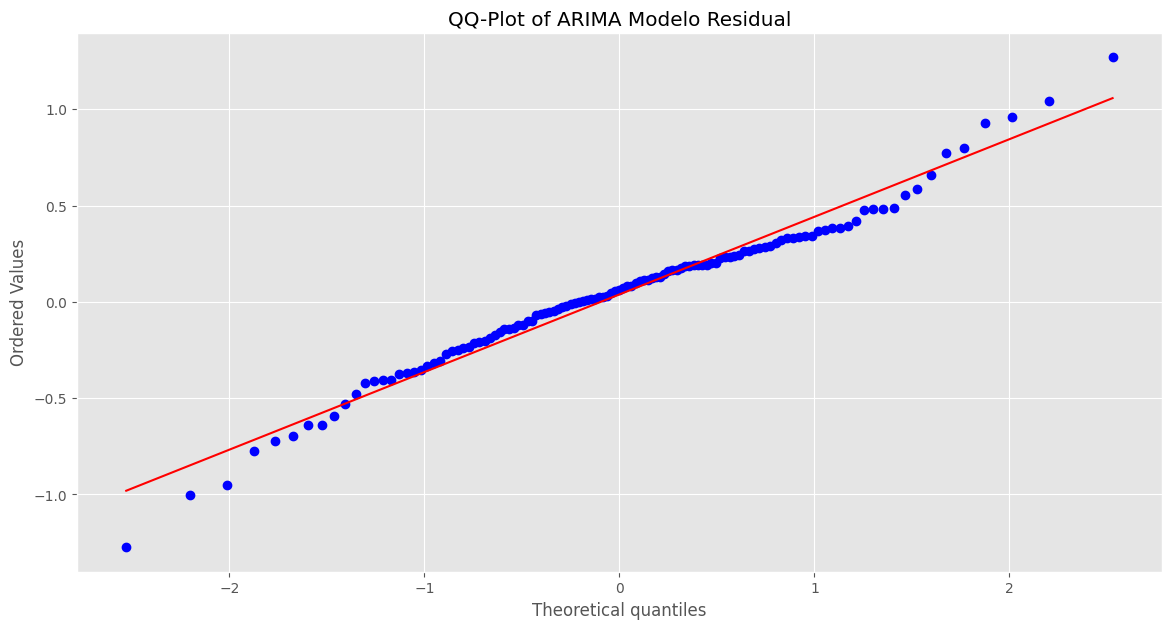

In [74]:
import scipy.stats as stats

# Histogram of Residuos
plt.figure(figsize=(14, 7))
plt.hist(residuals_arima, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histograma ARIMA Modelo Residual')
plt.xlabel('Valor Residual')
plt.ylabel('Frequencia')
plt.grid(True)
plt.show()

# QQ-plot para Residual
plt.figure(figsize=(14, 7))
stats.probplot(residuals_arima, dist="norm", plot=plt)
plt.title('QQ-Plot of ARIMA Modelo Residual')
plt.grid(True)
plt.show()

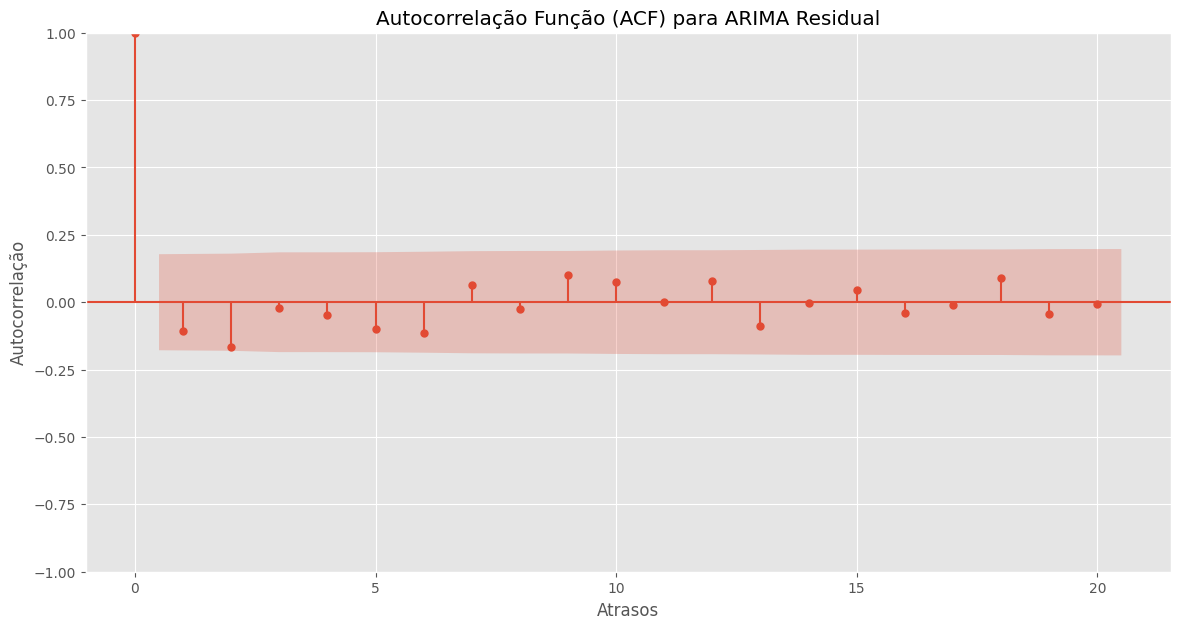

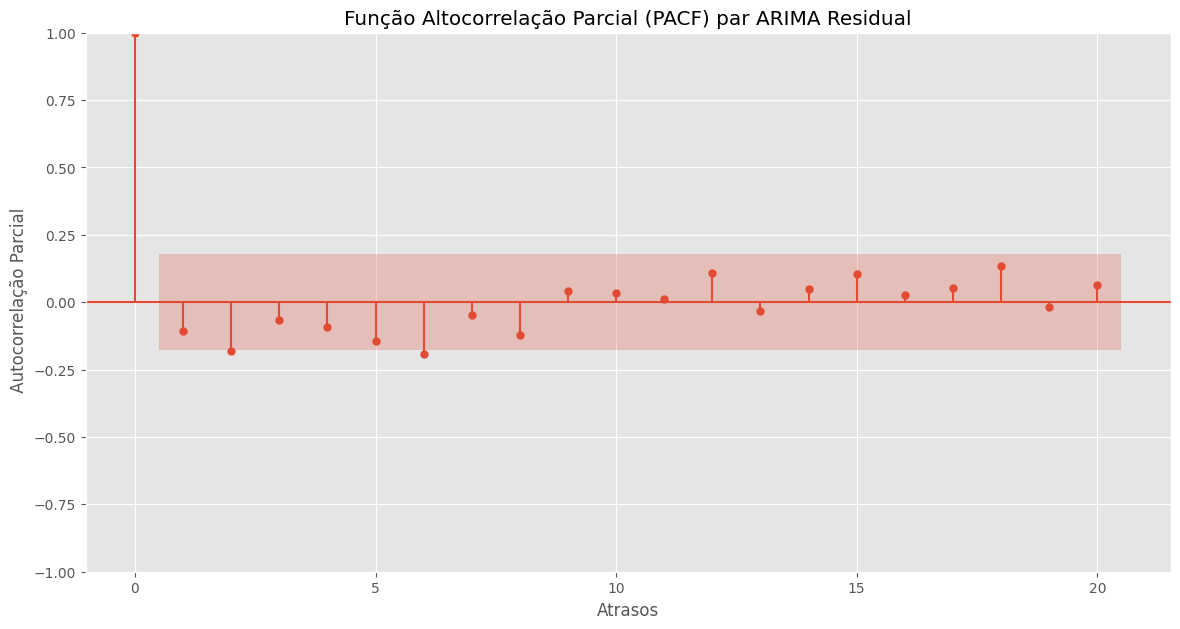

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF of Residual
plt.figure(figsize=(14, 7))
plot_acf(residuals_arima, lags=20, ax=plt.gca(), title='Autocorrelação Função (ACF) para ARIMA Residual')
plt.xlabel('Atrasos')
plt.ylabel('Autocorrelação')
plt.grid(True)
plt.show()

# PACF of Residual
plt.figure(figsize=(14, 7))
plot_pacf(residuals_arima, lags=20, ax=plt.gca(), title='Função Altocorrelação Parcial (PACF) par ARIMA Residual')
plt.xlabel('Atrasos')
plt.ylabel(' Autocorrelação Parcial')
plt.grid(True)
plt.show()

## Visualizar Previsões do ARIMA
Plotar a série IPCA original, as previsões do modelo ARIMA (in-sample) e as previsões futuras (out-of-sample) em um único gráfico, incluindo legendas e títulos apropriados.


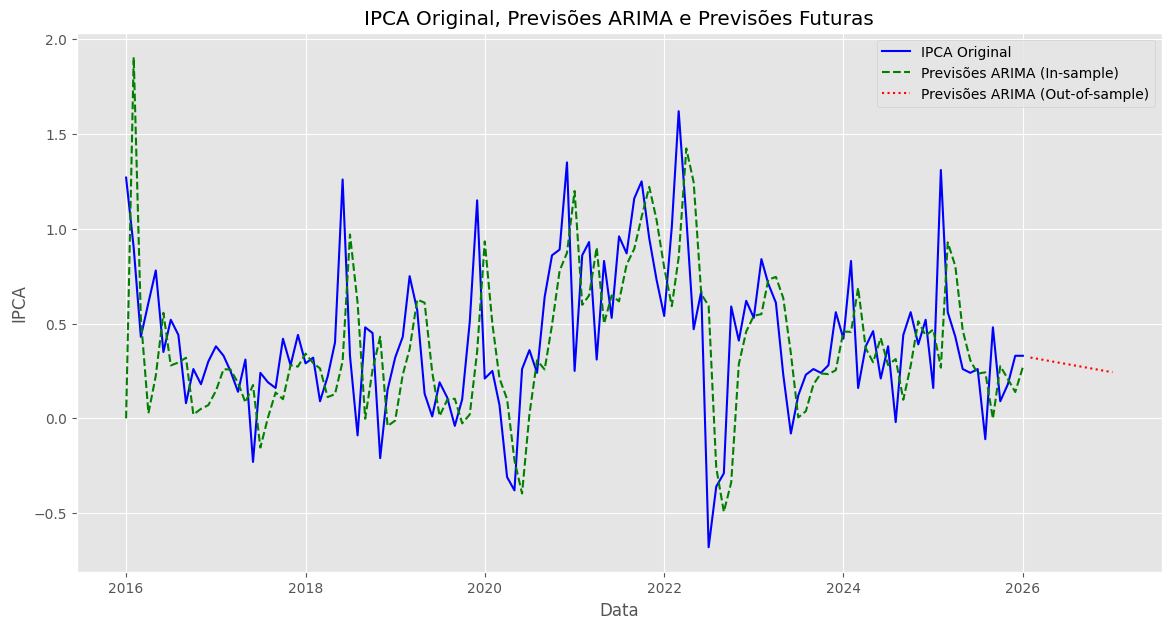

In [108]:
plt.figure(figsize=(14, 7))

# Plot IPCA Original
plt.plot(ipca['ipca'].index.to_timestamp(), ipca['ipca'], label='IPCA Original', color='blue')

# Plot Previsões ARIMA (In-sample)
plt.plot(arima_previsoes_insample.index.to_timestamp(), arima_previsoes_insample, label='Previsões ARIMA (In-sample)', color='green', linestyle='--')

# Plot Previsões Futuras ARIMA (Out-of-sample)
plt.plot(arima_previsoes_futuras.index.to_timestamp(), arima_previsoes_futuras, label='Previsões ARIMA (Out-of-sample)', color='red', linestyle=':')

# Adicionar título e rótulos
plt.title('IPCA Original, Previsões ARIMA e Previsões Futuras')
plt.xlabel('Data')
plt.ylabel('IPCA')
plt.legend()
plt.grid(True)
plt.show()

#Comparação de dados ARIMA E OLS



In [55]:
import pandas as pd

#Prepare series for concatenation with renaming
series_to_combine = {
    'IPCA Original': ipca['ipca'],
    'Previsões OLS Futuras': previsoes_futuras_ipca,
    'Previsões ARIMA Futuras': arima_previsoes_futuras
}

#Combine the series into a single DataFrame
df_combined_forecasts = pd.concat(series_to_combine, axis=1)

# Convert the index to DatetimeIndex
df_combined_forecasts.index = df_combined_forecasts.index.to_timestamp()

#Display the first and last lines of the combined DataFrame
print("First 5 rows of df_combined_forecasts:")
display(df_combined_forecasts.head())

print("\nLast 5 rows of df_combined_forecasts:")
display(df_combined_forecasts.tail())

First 5 rows of df_combined_forecasts:


,IPCA Original,Previsões OLS Futuras,Previsões ARIMA Futuras
2016-01-01,1.27,NaN,NaN
2016-02-01,0.90,NaN,NaN
2016-03-01,0.43,NaN,NaN
2016-04-01,0.61,NaN,NaN
2016-05-01,0.78,NaN,NaN



Last 5 rows of df_combined_forecasts:


,IPCA Original,Previsões OLS Futuras,Previsões ARIMA Futuras
2026-09-01,NaN,0.251548,0.271465
2026-10-01,NaN,0.251548,0.264368
2026-11-01,NaN,0.251548,0.257271
2026-12-01,NaN,0.251548,0.250174
2027-01-01,NaN,0.251548,0.243078



Plotar a série IPCA original, as previsões futuras do modelo OLS e as previsões futuras do modelo ARIMA em um único gráfico.


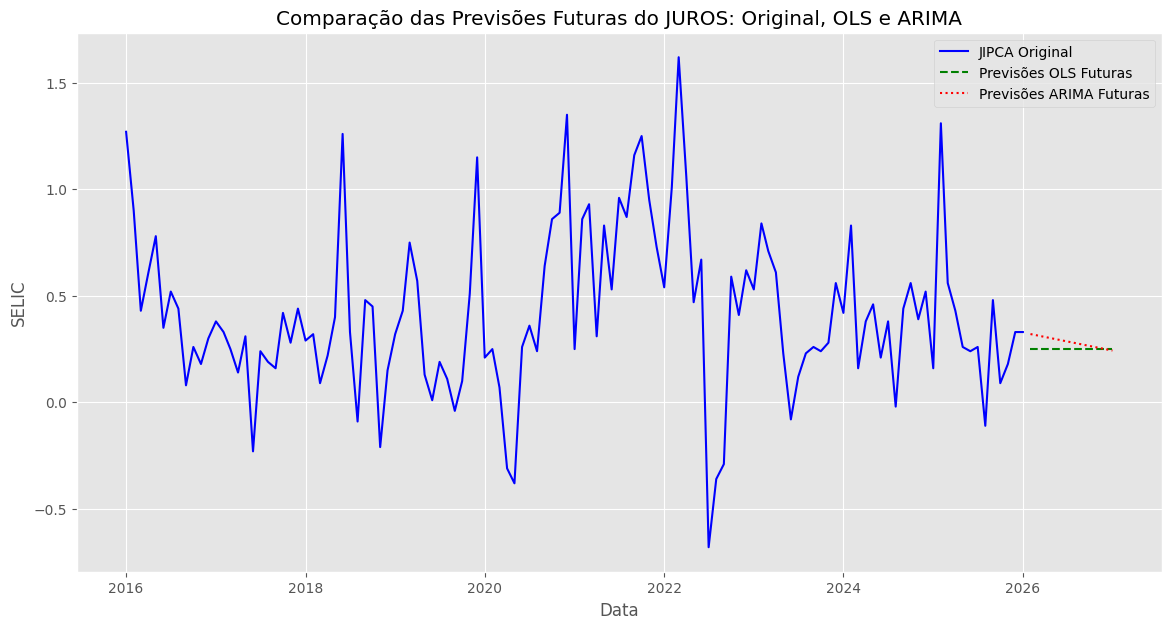

In [54]:
plt.figure(figsize=(14, 7))

# Plot IPCA Original
plt.plot(df_combined_forecasts.index, df_combined_forecasts['IPCA Original'], label='JIPCA Original', color='blue')

# Plot Previsões OLS Futuras
plt.plot(df_combined_forecasts.index, df_combined_forecasts['Previsões OLS Futuras'], label='Previsões OLS Futuras', color='green', linestyle='--')

# Plot Previsões ARIMA Futuras
plt.plot(df_combined_forecasts.index, df_combined_forecasts['Previsões ARIMA Futuras'], label='Previsões ARIMA Futuras', color='red', linestyle=':')

# Adicionar título e rótulos
plt.title('Comparação das Previsões Futuras do JUROS: Original, OLS e ARIMA')
plt.xlabel('Data')
plt.ylabel('SELIC')
plt.legend()
plt.grid(True)
plt.show()